
### Punto 'a': Uso de Algoritmos Genéticos para Feature Selection (Selección de Características)

**Objetivo:** Demostrar cómo los algoritmos genéticos pueden optimizar la selección de características para mejorar el rendimiento de un modelo de aprendizaje automático, reduciendo la dimensionalidad y evitando el sobreajuste.

**Contexto:** La selección de características es un paso crucial en el preprocesamiento de datos. Consiste en elegir un subconjunto de características relevantes para usar en la construcción del modelo. Un algoritmo genético puede explorar eficientemente el espacio de posibles combinaciones de características para encontrar el subconjunto óptimo.

**Ciclo del Algoritmo Genético:**

In [ ]:
# 1. Importar librerías necesarias
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import random

### 1. Generación del Dataset de Ejemplo

Creamos un dataset sintético con 1000 muestras y 20 características, de las cuales solo 10 son informativas. Esto nos permitirá ver cómo el AG puede identificar las características relevantes.

In [ ]:
# Generar un dataset sintético
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_redundant=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

Dimensiones de X_train: (700, 20)
Dimensiones de X_test: (300, 20)


### 2. Representación de la Población (Cromosomas)

Cada 'cromosoma' será un vector binario donde cada posición representa una característica. Un `1` indica que la característica está seleccionada y un `0` que no lo está. La longitud del cromosoma es igual al número total de características.

In [ ]:
# Parámetros del Algoritmo Genético
NUM_FEATURES = X.shape[1]
POPULATION_SIZE = 50
GENERATIONS = 50
MUTATION_RATE = 0.05
CROSSOVER_RATE = 0.8

# Función para inicializar la población
def initialize_population(num_features, population_size):
    population = []
    for _ in range(population_size):
        chromosome = [random.randint(0, 1) for _ in range(num_features)]
        population.append(chromosome)
    return population

# Inicializar la primera población
population = initialize_population(NUM_FEATURES, POPULATION_SIZE)
print(f"Ejemplo de cromosoma inicial: {population[0]}")

Ejemplo de cromosoma inicial: [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0]


### 3. Función de Aptitud (Fitness Function)

La función de aptitud evalúa qué tan 'bueno' es un cromosoma (un subconjunto de características). En este caso, entrenamos un modelo de Regresión Logística usando solo las características seleccionadas por el cromosoma y calculamos su precisión (accuracy) en el conjunto de prueba. Un mayor accuracy indica una mayor aptitud.

In [ ]:
# Función de aptitud: entrena un modelo y devuelve su precisión
def calculate_fitness(chromosome, X_train, X_test, y_train, y_test):
    # Obtener los índices de las características seleccionadas
    selected_features_indices = [i for i, bit in enumerate(chromosome) if bit == 1]

    # Si no se selecciona ninguna característica, la aptitud es 0
    if not selected_features_indices:
        return 0

    # Filtrar el dataset con las características seleccionadas
    X_train_selected = X_train[:, selected_features_indices]
    X_test_selected = X_test[:, selected_features_indices]

    # Entrenar un modelo de Regresión Logística
    model = LogisticRegression(solver='liblinear', random_state=42)
    model.fit(X_train_selected, y_train)

    # Calcular la precisión en el conjunto de prueba
    predictions = model.predict(X_test_selected)
    accuracy = accuracy_score(y_test, predictions)
    return accuracy

# Ejemplo de cálculo de aptitud para un cromosoma
example_chromosome = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0] # Selecciona la mitad de las características
fitness_score = calculate_fitness(example_chromosome, X_train, X_test, y_train, y_test)
print(f"Aptitud para un cromosoma de ejemplo: {fitness_score:.4f}")

Aptitud para un cromosoma de ejemplo: 0.8500


### 4. Selección

Utilizamos la selección por torneo. Se eligen aleatoriamente `k` individuos de la población y el individuo con la mejor aptitud de ese grupo es seleccionado como padre.

In [ ]:
# Selección por Torneo
def select_parent(population, fitness_scores, tournament_size=3):
    selected_indices = random.sample(range(len(population)), tournament_size)
    best_parent_index = selected_indices[0]
    for i in selected_indices:
        if fitness_scores[i] > fitness_scores[best_parent_index]:
            best_parent_index = i
    return population[best_parent_index]

### 5. Cruzamiento (Crossover)

Empleamos el cruzamiento de un solo punto. Se elige un punto de corte aleatorio en el cromosoma, y los hijos se forman combinando la primera parte de un padre con la segunda parte del otro.

In [ ]:
# Cruzamiento (Crossover) de un punto
def crossover(parent1, parent2):
    if random.random() < CROSSOVER_RATE:
        crossover_point = random.randint(1, len(parent1) - 1)
        child1 = parent1[:crossover_point] + parent2[crossover_point:]
        child2 = parent2[:crossover_point] + parent1[crossover_point:]
        return child1, child2
    return parent1, parent2

### 6. Mutación

Cada bit en el cromosoma tiene una pequeña probabilidad (`MUTATION_RATE`) de invertirse (de `0` a `1` o viceversa). Esto ayuda a introducir nueva diversidad genética y evitar caer en óptimos locales.

In [ ]:
# Mutación (Flip Bit Mutation)
def mutate(chromosome):
    for i in range(len(chromosome)):
        if random.random() < MUTATION_RATE:
            chromosome[i] = 1 - chromosome[i]  # Invertir el bit
    return chromosome

### 7. Ejecución del Algoritmo Genético y Terminación

El algoritmo se ejecuta durante un número predefinido de generaciones (`GENERATIONS`). En cada generación, se calcula la aptitud de cada individuo, se seleccionan padres, se cruzan y se mutan para formar la nueva población. Al final, se devuelve el mejor cromosoma (el subconjunto de características) encontrado y su aptitud.

In [ ]:
# Bucle principal del Algoritmo Genético
best_chromosome = None
best_fitness = -1

history_best_fitness = []

for generation in range(GENERATIONS):
    # Calcular aptitud para toda la población
    fitness_scores = [calculate_fitness(c, X_train, X_test, y_train, y_test) for c in population]

    # Encontrar el mejor individuo de la generación
    current_best_index = np.argmax(fitness_scores)
    if fitness_scores[current_best_index] > best_fitness:
        best_fitness = fitness_scores[current_best_index]
        best_chromosome = population[current_best_index]

    history_best_fitness.append(best_fitness)

    # Crear nueva población
    new_population = []
    for _ in range(POPULATION_SIZE // 2):
        parent1 = select_parent(population, fitness_scores)
        parent2 = select_parent(population, fitness_scores)
        child1, child2 = crossover(parent1, parent2)
        new_population.append(mutate(child1))
        new_population.append(mutate(child2))

    # Reemplazar la población antigua con la nueva
    population = new_population

    print(f"Generación {generation+1}: Mejor Aptitud = {best_fitness:.4f}, Características Seleccionadas = {sum(best_chromosome)}")

print("\n--- Resultados Finales ---")
print(f"Mejor subconjunto de características encontrado: {best_chromosome}")
print(f"Número de características seleccionadas: {sum(best_chromosome)}")
print(f"Precisión (Accuracy) del modelo con las características seleccionadas: {best_fitness:.4f}")

selected_feature_indices = [i for i, bit in enumerate(best_chromosome) if bit == 1]
print(f"Índices de las características seleccionadas: {selected_feature_indices}")

Generación 1: Mejor Aptitud = 0.8633, Características Seleccionadas = 12
Generación 2: Mejor Aptitud = 0.8633, Características Seleccionadas = 12
Generación 3: Mejor Aptitud = 0.8633, Características Seleccionadas = 12
Generación 4: Mejor Aptitud = 0.8667, Características Seleccionadas = 10
Generación 5: Mejor Aptitud = 0.8667, Características Seleccionadas = 10
Generación 6: Mejor Aptitud = 0.8667, Características Seleccionadas = 10
Generación 7: Mejor Aptitud = 0.8667, Características Seleccionadas = 10
Generación 8: Mejor Aptitud = 0.8667, Características Seleccionadas = 10
Generación 9: Mejor Aptitud = 0.8667, Características Seleccionadas = 10
Generación 10: Mejor Aptitud = 0.8733, Características Seleccionadas = 12
Generación 11: Mejor Aptitud = 0.8733, Características Seleccionadas = 12
Generación 12: Mejor Aptitud = 0.8733, Características Seleccionadas = 12
Generación 13: Mejor Aptitud = 0.8733, Características Seleccionadas = 12
Generación 14: Mejor Aptitud = 0.8733, Caracter

### 8. Visualización de la convergencia

Podemos graficar cómo mejora la mejor aptitud a lo largo de las generaciones para ver la convergencia del algoritmo.

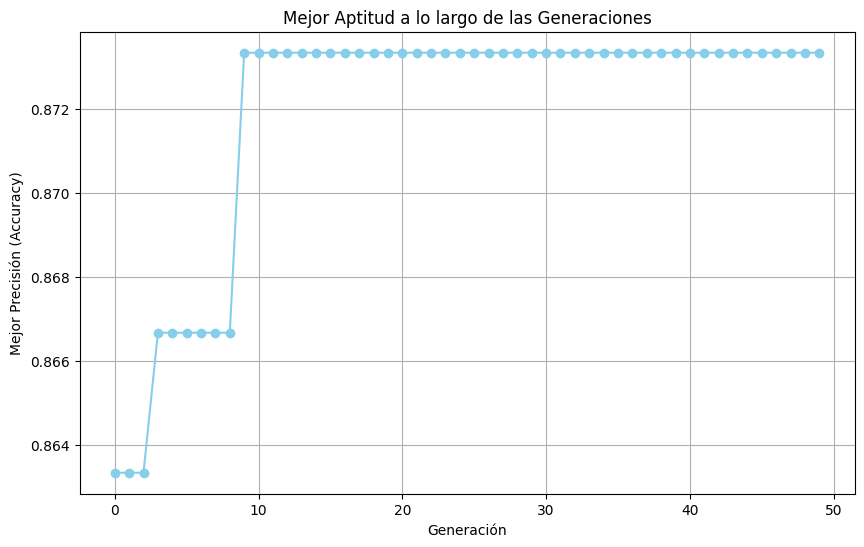

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history_best_fitness, marker='o', linestyle='-', color='skyblue')
plt.title('Mejor Aptitud a lo largo de las Generaciones')
plt.xlabel('Generación')
plt.ylabel('Mejor Precisión (Accuracy)')
plt.grid(True)
plt.show()

### Conclusión del Punto 'a'

Este ejemplo demuestra cómo un Algoritmo Genético puede ser utilizado para la selección de características. A través de la iteración de los pasos de inicialización, aptitud, selección, cruzamiento y mutación, el algoritmo converge hacia un subconjunto de características que optimiza el rendimiento del modelo de clasificación. Podemos observar que el número de características seleccionadas es menor al total, y que el modelo logra una buena precisión, validando la utilidad de esta técnica para reducir la dimensionalidad y potencialmente mejorar la generalización del modelo.